In [ ]:
import pandas as pd
import numpy as np


# ============================================================
# НАСТРОЙКИ
# ============================================================

INPUT_FILE = r"C:\Users\user\Desktop\Праметрический расчет\НКТЭЦ ГТ3 1 квартальный 2026.xlsx"
OUTPUT_FILE = r"C:\Users\user\Desktop\Праметрический расчет\result_windows.xlsx"

SHEET_NAME = "Данные"

LOW_POWER = 10
GAP_SIZE = 7 * 48          # 7 суток = 336 записей

WINDOW_SIZE = 48           # одно окно = 48 записей
DAYS_ZONE = 10
ZONE_SIZE = 48 * DAYS_ZONE  # 480 записей

K_TOLERANCE = 0.05         # 5%
B_TOLERANCE = 0.05         # 5%


# ============================================================
# ОТНОСИТЕЛЬНАЯ РАЗНИЦА
# ============================================================

def relative_diff(a, b):

    denominator = abs(a)

    if denominator < 1e-12:
        if abs(b) < 1e-12:
            return 0.0
        return np.inf

    return abs(a - b) / denominator * 100


# ============================================================
# РЕГРЕССИЯ ДЛЯ ОКНА
#
# fuel = k * power + b
#
# X = power
# Y = fuel
# ============================================================

def calculate_window(window):

    power = pd.to_numeric(
        window["power"],
        errors="coerce"
    ).to_numpy(dtype=float)

    fuel = pd.to_numeric(
        window["fuel"],
        errors="coerce"
    ).to_numpy(dtype=float)

    # Ровно 48 записей
    if len(power) != WINDOW_SIZE:
        return None

    # Нет пропусков
    if np.isnan(power).any() or np.isnan(fuel).any():
        return None

    # Мощность не должна быть постоянной
    if np.std(power) < 1e-12:
        return None

    # fuel = k * power + b
    k, b = np.polyfit(power, fuel, 1)

    # R²
    if np.std(fuel) < 1e-12:
        r2 = 0.0
    else:
        r = np.corrcoef(power, fuel)[0, 1]
        r2 = r ** 2

    return k, b, r2


# ============================================================
# СОЗДАНИЕ СКОЛЬЗЯЩИХ ОКОН
# ============================================================

def make_windows(period_df, zone_type, period_number):

    windows = []

    # --------------------------------------------------------
    # Зона
    # --------------------------------------------------------

    if zone_type == "START":
        zone = period_df.iloc[:ZONE_SIZE].copy()
    else:
        zone = period_df.iloc[-ZONE_SIZE:].copy()

    # --------------------------------------------------------
    # Скользящее окно 48 записей
    # шаг = 1 запись
    # --------------------------------------------------------

    for i in range(
        len(zone) - WINDOW_SIZE + 1
    ):

        window = zone.iloc[
            i:i + WINDOW_SIZE
        ]

        metrics = calculate_window(window)

        if metrics is None:
            continue

        k, b, r2 = metrics

        windows.append({

            "period": period_number,

            "type": zone_type,

            "window_id":
                f"{zone_type}_{i + 1:03d}",

            "window_start":
                window["date"].iloc[0],

            "window_end":
                window["date"].iloc[-1],

            "k": k,

            "b": b,

            "R2": r2,
        })

    return pd.DataFrame(windows)


# ============================================================
# ПОИСК ПАР
# ============================================================

def find_pairs(start_windows, end_windows):

    pairs = []

    # ========================================================
    # START × END
    # ========================================================

    for _, start in start_windows.iterrows():

        for _, end in end_windows.iterrows():

            k1 = float(start["k"])
            k2 = float(end["k"])

            b1 = float(start["b"])
            b2 = float(end["b"])

            delta_k = abs(k1 - k2)
            delta_k_pct = relative_diff(k1, k2)

            delta_b = abs(b1 - b2)
            delta_b_pct = relative_diff(b1, b2)

            pairs.append({

                "period":
                    start["period"],

                "start_id":
                    start["window_id"],

                "end_id":
                    end["window_id"],

                "start_begin":
                    start["window_start"],

                "start_end":
                    start["window_end"],

                "end_begin":
                    end["window_start"],

                "end_end":
                    end["window_end"],

                "k_start":
                    k1,

                "k_end":
                    k2,

                "delta_k":
                    delta_k,

                "delta_k_pct":
                    delta_k_pct,

                "b_start":
                    b1,

                "b_end":
                    b2,

                "delta_b":
                    delta_b,

                "delta_b_pct":
                    delta_b_pct,

                "R2_start":
                    start["R2"],

                "R2_end":
                    end["R2"],
            })

    pairs_df = pd.DataFrame(pairs)

    if pairs_df.empty:
        return pd.DataFrame(), pd.DataFrame()

    # ========================================================
    # ШАГ 1 — оставляем пары с Δk <= 5%
    # ========================================================

    pairs_k = pairs_df[
        np.isfinite(pairs_df["delta_k_pct"]) &
        (pairs_df["delta_k_pct"] <= K_TOLERANCE * 100)
    ].copy()


    # ========================================================
    # ШАГ 2 — среди них оставляем пары с Δb <= 5%
    # ========================================================

    pairs_b = pairs_k[
        np.isfinite(pairs_k["delta_b_pct"]) &
        (pairs_k["delta_b_pct"] <= B_TOLERANCE * 100)
    ].copy()


    # ========================================================
    # ЕСЛИ ЕСТЬ ПАРЫ, ПРОШЕДШИЕ ОБА ФИЛЬТРА
    # ========================================================

    if not pairs_b.empty:

        pairs_b = pairs_b.sort_values(
            [
                "delta_k_pct",
                "delta_b_pct"
            ],
            ascending=[
                True,
                True
            ]
        ).reset_index(drop=True)

        top3 = pairs_b.head(3).copy()

        top3["status"] = (
            "Прошла фильтры Δk ≤ 5% и Δb ≤ 5%"
        )

        return top3, pairs_b


    # ========================================================
    # ЕСЛИ НЕТ ПАРЫ ≤5% ПО ОБОИМ ПАРАМЕТРАМ
    #
    # Показываем ближайшие 3 пары
    # ========================================================

    nearest = pairs_df.sort_values(
        ["delta_k_pct", "delta_b_pct"],
        na_position="last"
    ).head(3).copy()

    nearest["status"] = (
        "Нет пары ≤5%; показаны ближайшие"
    )

    return nearest, pairs_b


# ============================================================
# ОПРЕДЕЛЕНИЕ ПЕРИОДОВ
#
# power <= 10 в течение 7 суток
# = граница периода
# ============================================================

def detect_periods(df):

    df = df.copy()

    df["period"] = 0

    current_period = 1

    low_power_count = 0

    in_long_stop = False

    for i in range(len(df)):

        power = df.loc[i, "power"]

        if pd.isna(power):
            continue

        # ----------------------------------------------------
        # Простой
        # ----------------------------------------------------

        if power <= LOW_POWER:

            low_power_count += 1

            if low_power_count >= GAP_SIZE:
                in_long_stop = True

            continue

        # ----------------------------------------------------
        # Работа: power > 10
        # ----------------------------------------------------

        if in_long_stop:

            current_period += 1

            in_long_stop = False

        df.loc[i, "period"] = current_period

        low_power_count = 0

    return df


# ============================================================
# ОСНОВНАЯ ПРОГРАММА
# ============================================================

def main():

    print("Загрузка данных...")

    # --------------------------------------------------------
    # C  = дата
    # AZ = мощность
    # BF = расход топлива
    # --------------------------------------------------------

    df = pd.read_excel(
        INPUT_FILE,
        sheet_name=SHEET_NAME,
        usecols="B,AZ,BF"
    )

    df.columns = [
        "date",
        "power",
        "fuel"
    ]

    df["date"] = pd.to_datetime(
        df["date"],
        errors="coerce"
    )

    df["power"] = pd.to_numeric(
        df["power"],
        errors="coerce"
    )

    df["fuel"] = pd.to_numeric(
        df["fuel"],
        errors="coerce"
    )

    df = df.dropna(
        subset=["date"]
    )

    df = df.sort_values(
        "date"
    ).reset_index(drop=True)

    print(
        f"Загружено строк: {len(df)}"
    )

    # ========================================================
    # ОПРЕДЕЛЯЕМ ПЕРИОДЫ
    # ========================================================

    df = detect_periods(df)

    # ========================================================
    # УБИРАЕМ ПРОСТОЙ
    #
    # В анализ попадают только power > 10
    # ========================================================

    df = df[
        (df["period"] > 0) &
        (df["power"] > LOW_POWER)
    ].copy()

    df = df.reset_index(drop=True)

    # ========================================================
    # РЕЗУЛЬТАТЫ
    # ========================================================

    all_windows = []

    all_pairs = []

    results = []

    # ========================================================
    # ОБРАБОТКА ПЕРИОДОВ
    # ========================================================

    for period_number, period_df in df.groupby(
        "period"
    ):

        period_df = (
            period_df
            .reset_index(drop=True)
        )

        n = len(period_df)

        print()

        print(
            f"Период {period_number}: "
            f"{n} записей"
        )

        # ----------------------------------------------------
        # Нужно минимум 10 суток
        # ----------------------------------------------------

        if n < ZONE_SIZE:

            print(
                "  Период меньше 10 суток — пропуск"
            )

            continue

        # ----------------------------------------------------
        # Если период короче 20 суток,
        # START и END зоны будут пересекаться.
        # Это допустимо.
        # ----------------------------------------------------

        if n < ZONE_SIZE * 2:

            print(
                "  Внимание: первые и последние "
                "10 суток пересекаются."
            )

        # ====================================================
        # START
        # ====================================================

        start_windows = make_windows(
            period_df,
            "START",
            period_number
        )

        # ====================================================
        # END
        # ====================================================

        end_windows = make_windows(
            period_df,
            "END",
            period_number
        )

        print(
            f"  START окон: {len(start_windows)}"
        )

        print(
            f"  END окон:   {len(end_windows)}"
        )

        if (
            start_windows.empty or
            end_windows.empty
        ):

            print(
                "  Недостаточно корректных окон"
            )

            continue

        # ----------------------------------------------------
        # Сохраняем все окна
        # ----------------------------------------------------

        all_windows.append(
            start_windows
        )

        all_windows.append(
            end_windows
        )

        # ====================================================
        # ИЩЕМ ПАРЫ
        # ====================================================

        top3, pairs_final = find_pairs(
            start_windows,
            end_windows
        )

        if top3.empty:

            print(
                "  Не удалось подобрать пару"
            )

            continue

        # ----------------------------------------------------
        # Сохраняем пары, прошедшие оба фильтра
        # ----------------------------------------------------

        if not pairs_final.empty:

            all_pairs.append(
                pairs_final.copy()
            )

        # ====================================================
        # ТОП-3
        # ====================================================

        for rank, row in enumerate(
            top3.itertuples(index=False),
            start=1
        ):

            results.append({

                "period":
                    period_number,

                "rank":
                    rank,

                "status":
                    row.status,

                # START
                "start_window_id":
                    row.start_id,

                "start_window_begin":
                    row.start_begin,

                "start_window_end":
                    row.start_end,

                # END
                "end_window_id":
                    row.end_id,

                "end_window_begin":
                    row.end_begin,

                "end_window_end":
                    row.end_end,

                # K
                "k_start":
                    row.k_start,

                "k_end":
                    row.k_end,

                "delta_k":
                    row.delta_k,

                "delta_k_pct":
                    row.delta_k_pct,

                # B
                "b_start":
                    row.b_start,

                "b_end":
                    row.b_end,

                "delta_b":
                    row.delta_b,

                "delta_b_pct":
                    row.delta_b_pct,

                # R²
                "R2_start":
                    row.R2_start,

                "R2_end":
                    row.R2_end,
            })

            # ------------------------------------------------
            # Вывод в консоль
            # ------------------------------------------------

            print()

            print(
                f"  Вариант №{rank}"
            )

            print(
                f"    START: "
                f"{row.start_begin} "
                f"→ "
                f"{row.start_end}"
            )

            print(
                f"    END:   "
                f"{row.end_begin} "
                f"→ "
                f"{row.end_end}"
            )

            print(
                f"    Δk = "
                f"{float(row.delta_k_pct):.3f}%"
            )

            print(
                f"    Δb = "
                f"{float(row.delta_b_pct):.3f}%"
            )

            print(
                f"    {row.status}"
            )
            

    # ========================================================
    # ПОДГОТОВКА EXCEL
    # ========================================================

    result_df = pd.DataFrame(results)

    if all_windows:

        windows_df = pd.concat(
            all_windows,
            ignore_index=True
        )

    else:

        windows_df = pd.DataFrame()

    if all_pairs:

        pairs_df = pd.concat(
            all_pairs,
            ignore_index=True
        )

    else:

        pairs_df = pd.DataFrame()

    # ========================================================
    # СОХРАНЕНИЕ
    # ========================================================

    print()
    print("Сохранение...")

    # with pd.ExcelWriter(
    #     OUTPUT_FILE,
    #     engine="openpyxl"
    # ) as writer:

    #     result_df.to_excel(
    #         writer,
    #         sheet_name="Результат",
    #         index=False
    #     )

    #     windows_df.to_excel(
    #         writer,
    #         sheet_name="Все окна",
    #         index=False
    #     )

    #     pairs_df.to_excel(
    #         writer,
    #         sheet_name="Подходящие пары",
    #         index=False
    #     )
       
    print()
    print("ГОТОВО!")

    print(
        f"Результат сохранен: "
        f"{OUTPUT_FILE}"
    )
    return df, results, all_windows


# ============================================================
# ЗАПУСК
# ============================================================

df, results, all_windows = main()

Загрузка данных...
Загружено строк: 9846

Период 1: 6499 записей
  START окон: 433
  END окон:   433

  Вариант №1
    START: 2025-12-18 08:30:00 → 2025-12-19 08:00:00
    END:   2026-04-22 05:59:00 → 2026-04-23 05:29:00
    Δk = 0.012%
    Δb = 4.838%
    Прошла фильтры Δk ≤ 5% и Δb ≤ 5%

  Вариант №2
    START: 2025-12-18 08:30:00 → 2025-12-19 08:00:00
    END:   2026-04-22 04:29:00 → 2026-04-23 03:59:00
    Δk = 0.036%
    Δb = 4.102%
    Прошла фильтры Δk ≤ 5% и Δb ≤ 5%

  Вариант №3
    START: 2025-12-19 10:00:00 → 2025-12-20 09:30:00
    END:   2026-04-28 04:59:00 → 2026-04-29 04:29:00
    Δk = 0.053%
    Δb = 4.566%
    Прошла фильтры Δk ≤ 5% и Δb ≤ 5%

Период 2: 1580 записей
  START окон: 433
  END окон:   433

  Вариант №1
    START: 2026-07-16 12:03:00 → 2026-07-17 11:33:00
    END:   2026-08-08 18:33:00 → 2026-08-09 18:03:00
    Δk = 0.000%
    Δb = 2.490%
    Прошла фильтры Δk ≤ 5% и Δb ≤ 5%

  Вариант №2
    START: 2026-07-13 09:33:00 → 2026-07-14 09:03:00
    END:   2026-

Построение графиков: 6 вариантов


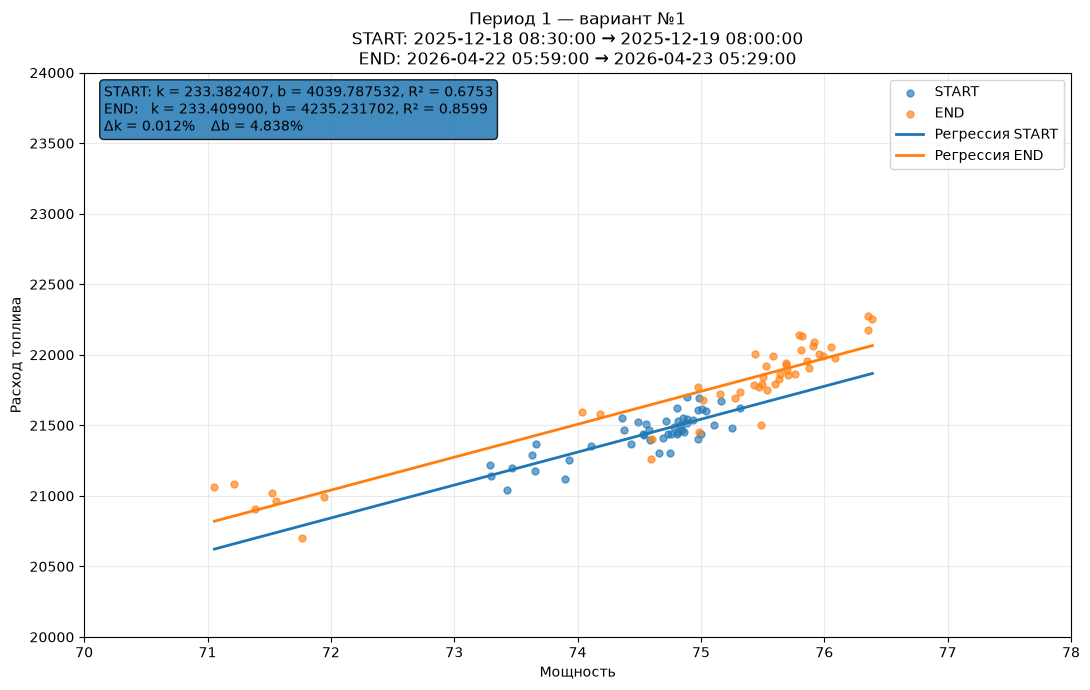

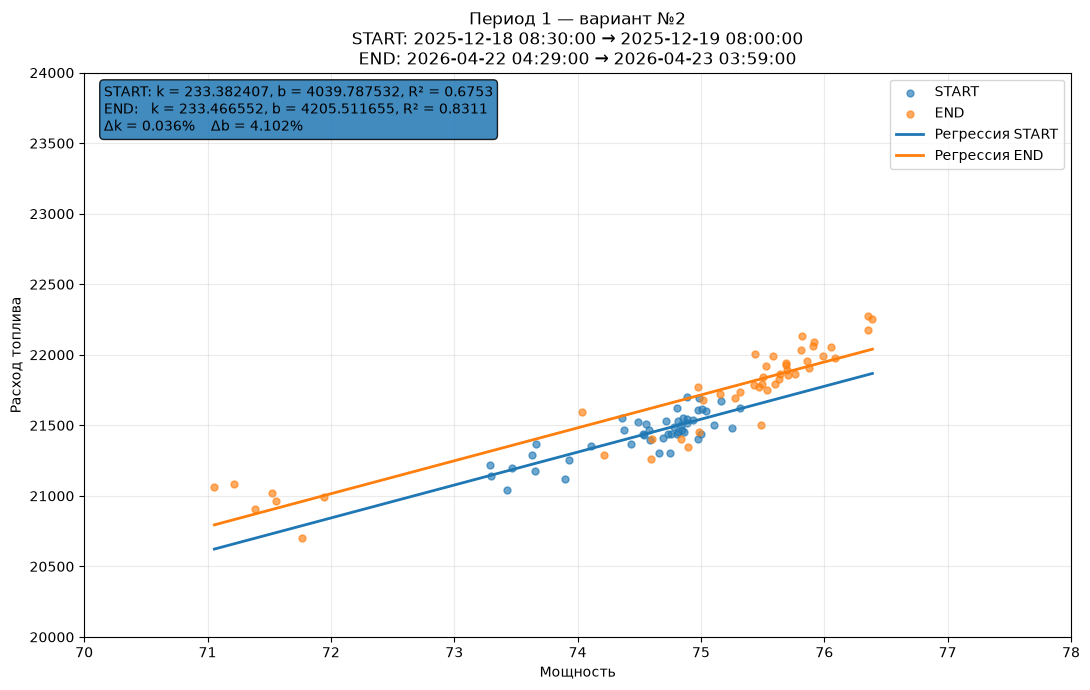

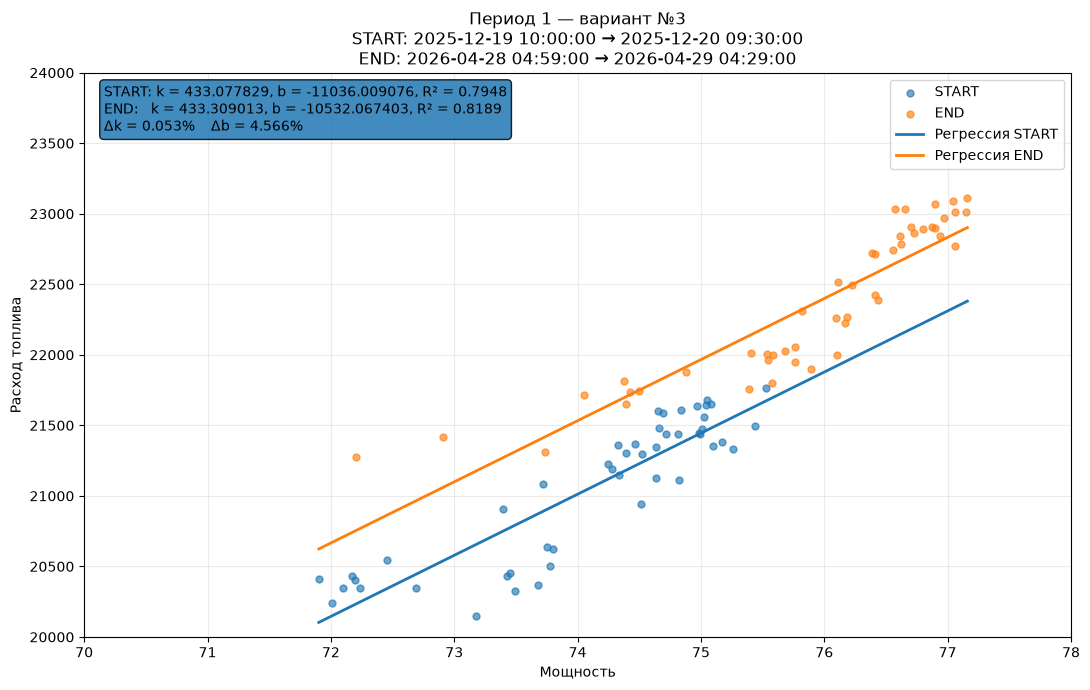

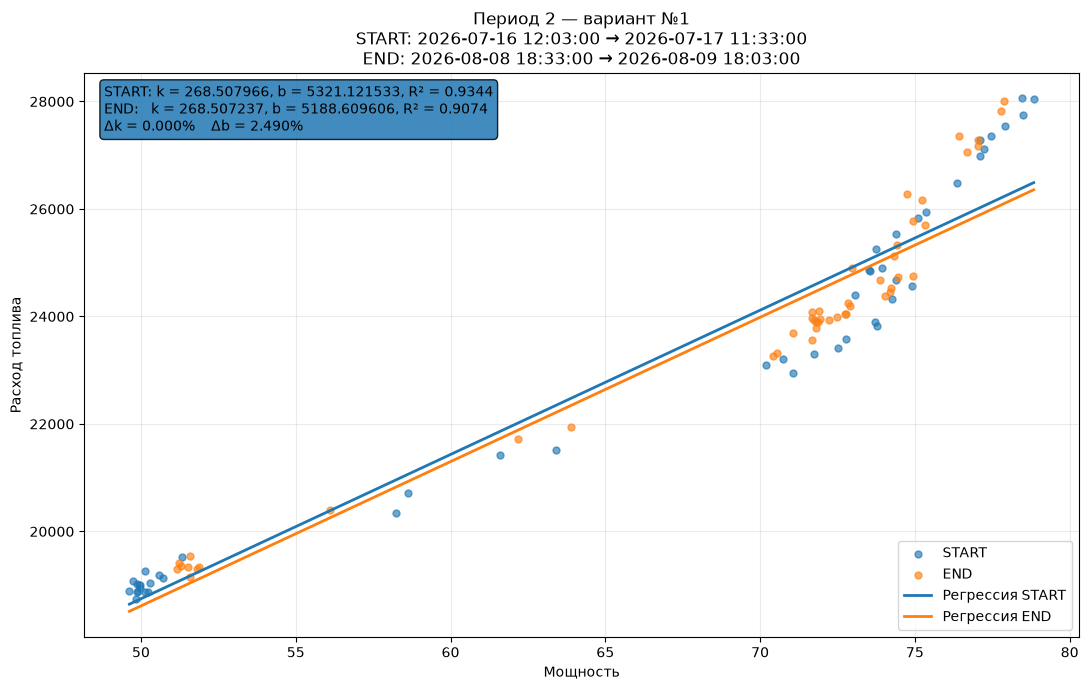

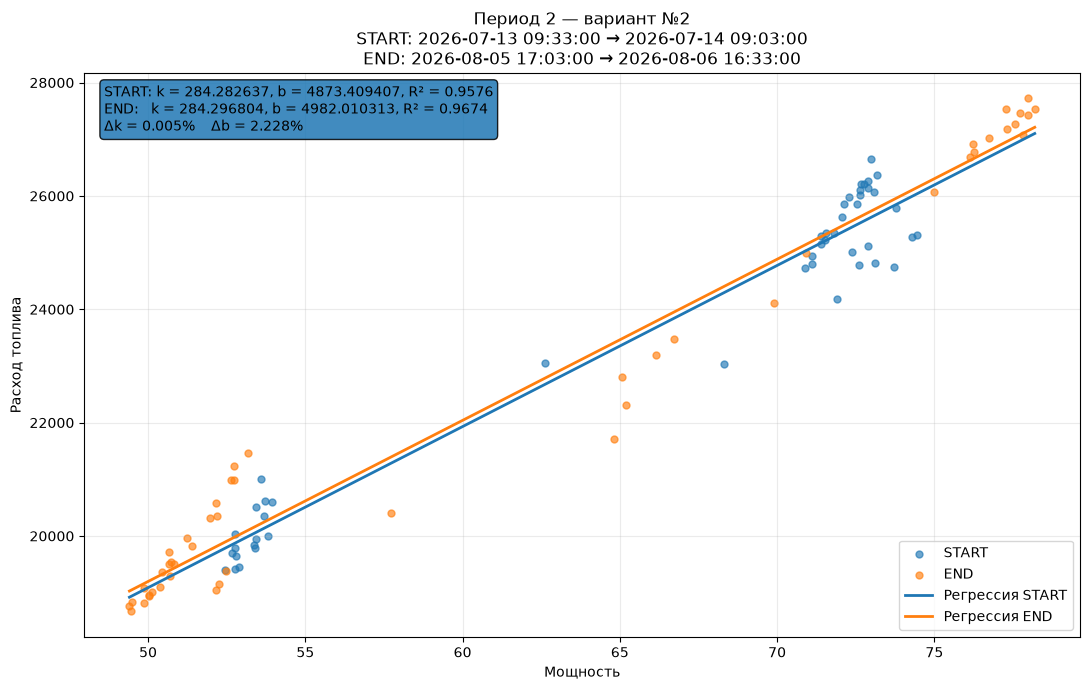

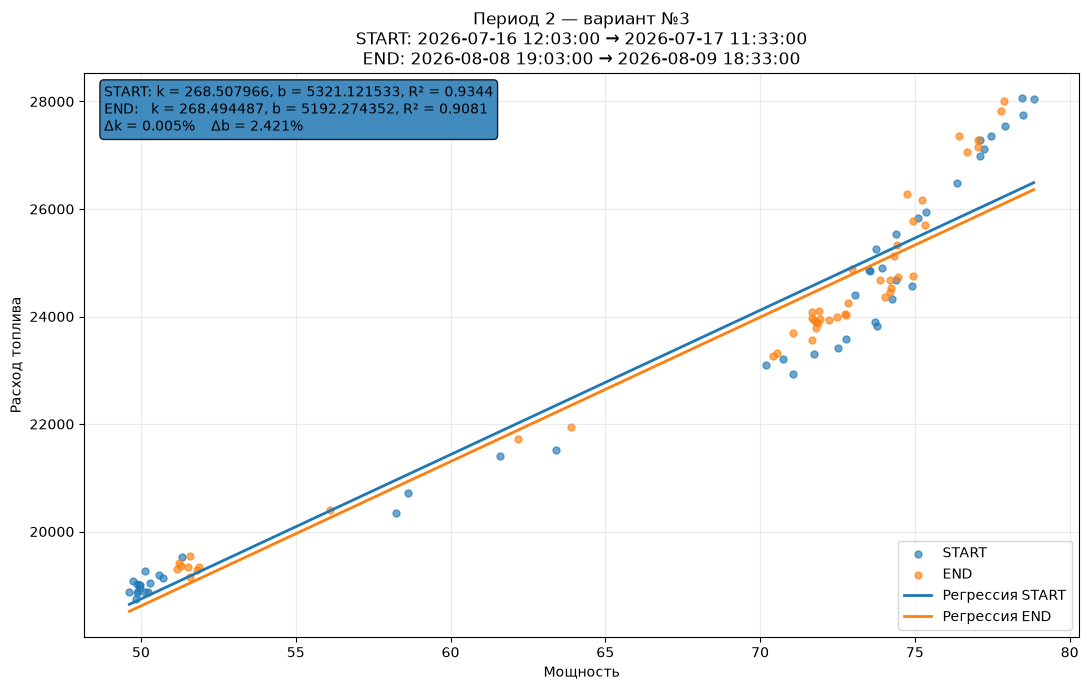

In [2]:
import matplotlib.pyplot as plt


# ============================================================
# НАСТРОЙКИ МАСШТАБА
#
# None = автоматический масштаб
#
# Пример:
# 1: (110000, 150000)
# означает Y от 110000 до 150000
# ============================================================

Y_LIMITS = {
    1: (20000, 24000),
    2: None,
}


# ============================================================
# МАСШТАБ X
#
# None = автоматический
# ============================================================

X_LIMITS = {
    1: (70, 78),
    2: None,
}


# ============================================================
# ПОСТРОЕНИЕ ГРАФИКОВ
# ============================================================

def plot_selected_windows():

    if not results:
        print("Нет найденных результатов.")
        return

    print(
        f"Построение графиков: "
        f"{len(results)} вариантов"
    )

    for result in results:

        period = result["period"]
        rank = result["rank"]

        # ====================================================
        # ДАННЫЕ ОКОН
        # ====================================================

        start_begin = result["start_window_begin"]
        start_end = result["start_window_end"]

        end_begin = result["end_window_begin"]
        end_end = result["end_window_end"]

        start_data = df[
            (df["period"] == period) &
            (df["date"] >= start_begin) &
            (df["date"] <= start_end)
        ].copy()

        end_data = df[
            (df["period"] == period) &
            (df["date"] >= end_begin) &
            (df["date"] <= end_end)
        ].copy()

        if start_data.empty or end_data.empty:
            print(
                f"Период {period}, вариант {rank}: "
                f"данные не найдены"
            )
            continue

        # ====================================================
        # КОЭФФИЦИЕНТЫ РЕГРЕССИИ
        # ====================================================

        k_start = result["k_start"]
        b_start = result["b_start"]

        k_end = result["k_end"]
        b_end = result["b_end"]

        # ====================================================
        # ГРАФИК
        # ====================================================

        fig, ax = plt.subplots(
            figsize=(11, 7)
        )

        # START
        ax.scatter(
            start_data["power"],
            start_data["fuel"],
            s=25,
            alpha=0.65,
            label="START"
        )

        # END
        ax.scatter(
            end_data["power"],
            end_data["fuel"],
            s=25,
            alpha=0.65,
            label="END"
        )

        # ====================================================
        # РЕГРЕССИИ
        # ====================================================

        all_power = pd.concat([
            start_data["power"],
            end_data["power"]
        ])

        x_min = all_power.min()
        x_max = all_power.max()

        x_line = np.linspace(
            x_min,
            x_max,
            100
        )

        y_start = (
            k_start * x_line +
            b_start
        )

        y_end = (
            k_end * x_line +
            b_end
        )

        ax.plot(
            x_line,
            y_start,
            linewidth=2,
            label="Регрессия START"
        )

        ax.plot(
            x_line,
            y_end,
            linewidth=2,
            label="Регрессия END"
        )

        # ====================================================
        # РУЧНОЙ / АВТОМАТИЧЕСКИЙ Y
        # ====================================================

        if Y_LIMITS.get(period) is not None:

            ax.set_ylim(
                Y_LIMITS[period][0],
                Y_LIMITS[period][1]
            )

        # ====================================================
        # РУЧНОЙ / АВТОМАТИЧЕСКИЙ X
        # ====================================================

        if X_LIMITS.get(period) is not None:

            ax.set_xlim(
                X_LIMITS[period][0],
                X_LIMITS[period][1]
            )

        # ====================================================
        # ПОДПИСИ
        # ====================================================

        ax.set_xlabel("Мощность")
        ax.set_ylabel("Расход топлива")

        ax.set_title(
            f"Период {period} — вариант №{rank}\n"
            f"START: {start_begin} → {start_end}\n"
            f"END: {end_begin} → {end_end}"
        )

        # ====================================================
        # ИНФОРМАЦИЯ
        # ====================================================

        text = (
            f"START: k = {k_start:.6f}, "
            f"b = {b_start:.6f}, "
            f"R² = {result['R2_start']:.4f}\n"
            f"END:   k = {k_end:.6f}, "
            f"b = {b_end:.6f}, "
            f"R² = {result['R2_end']:.4f}\n"
            f"Δk = {result['delta_k_pct']:.3f}%    "
            f"Δb = {result['delta_b_pct']:.3f}%"
        )

        ax.text(
            0.02,
            0.98,
            text,
            transform=ax.transAxes,
            verticalalignment="top",
            bbox=dict(
                boxstyle="round",
                alpha=0.85
            )
        )

        ax.grid(
            True,
            alpha=0.25
        )

        ax.legend()

        plt.tight_layout()
        plt.show()


plot_selected_windows()